# Solve 5 seeds per point cloud size and investigate solving duration

In [1]:
import sys

sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np

from typing import Any
from icp import ICP
from experiment_runner import fit_multi_seed
from matcher import NearestNeighborMatcher
from visualization import ErrorMetricsVisualizer
from algebra_utils import sample_dispersed_rotations
import numpy as np
from sklearn.cluster import DBSCAN
from experiment_runner import MultiSeedSyntheticICPResult

from feature_extractor import RobustGeometricFeatureExtractor
from trimmer import ClusteringTrimmer

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 5
N_STARTS = 13

# Synthetic experiment parameters
NUM_POINTS = [1000, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000]
NOISE_STD = 0.1
T_SCALE = 8.0
STYLE = 'muscle-fiber'
experiment_kwargs: dict[str, Any] = {'noise_std': NOISE_STD, 't_scale': T_SCALE, 'style': STYLE}

# Trimmer
K = 19
EPS_SCALING=0.1246
MIN_SAMPLES_SCALING=0.7766
CLUSTER_EPS = (2 * RobustGeometricFeatureExtractor.target_dim) ** 0.5 * EPS_SCALING
MIN_CLUSTER_FRACTION = 0.0131

In [2]:
matcher = NearestNeighborMatcher(feature_extractor=None)
icp = ICP(matcher=matcher, init_align_centroids=True, max_iter=MAX_ITER, record_history=False).to_multi_start(n_starts=N_STARTS, rotation_sampler=sample_dispersed_rotations)

In [ ]:
seeds = list(range(N_SEEDS))

results: list[MultiSeedSyntheticICPResult] = []
for n in NUM_POINTS:
    min_samples = max(2, int(np.log(n) * MIN_SAMPLES_SCALING))
    trimmer=ClusteringTrimmer(
        feature_extractor=RobustGeometricFeatureExtractor(k=K), 
        min_cluster_fraction=MIN_CLUSTER_FRACTION,
        clusterer=DBSCAN(eps=CLUSTER_EPS, min_samples=min_samples)
    )
    experiment_kwargs['n'] = n
    result = fit_multi_seed(icp, trimmer=trimmer, experiment_kwargs=experiment_kwargs, seeds=seeds)
    results.append(result)

Solving 5 seeds:   0%|          | 0/5 [00:00<?, ?it/s]

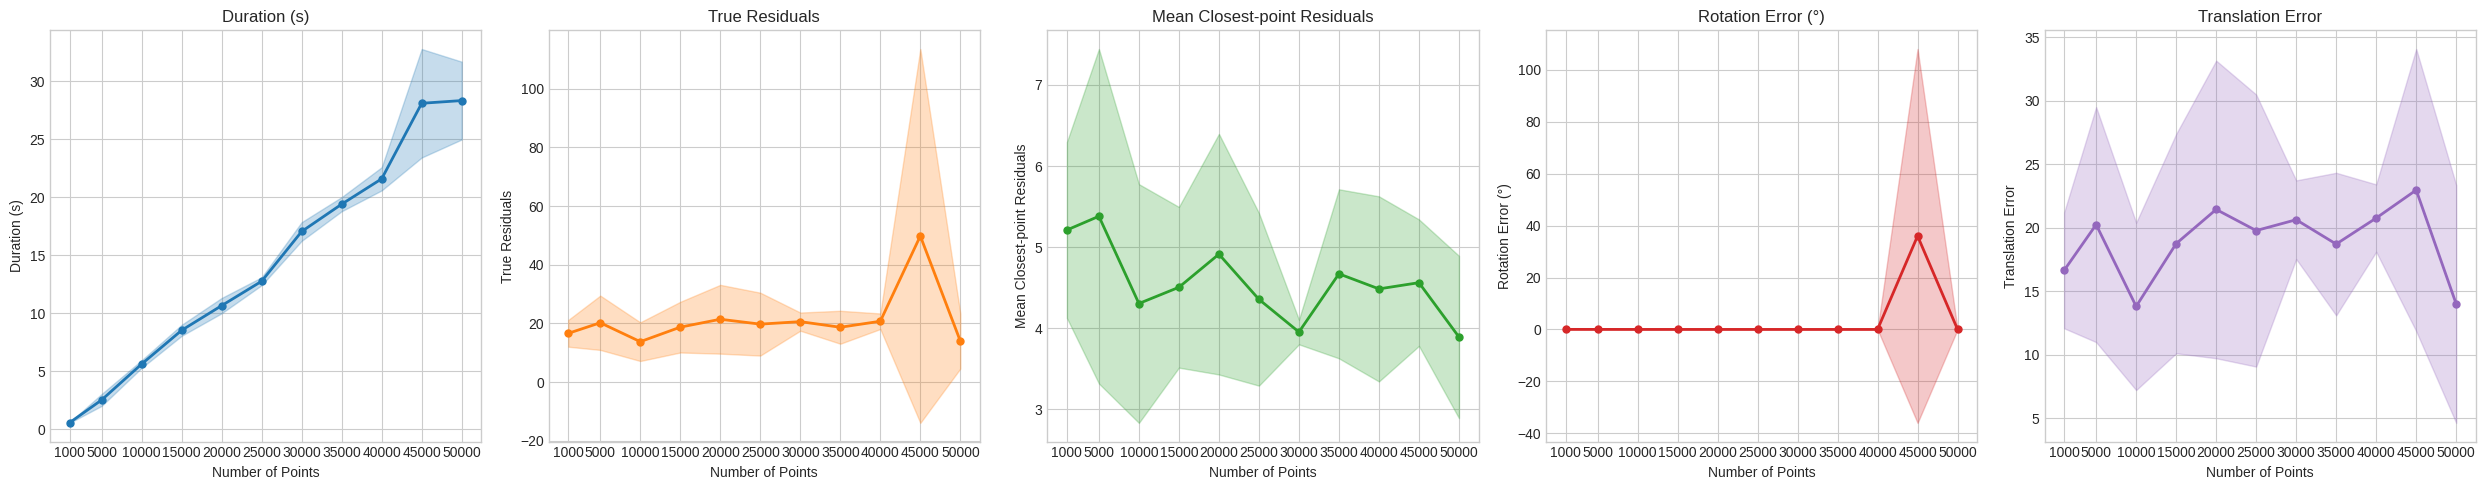

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
ErrorMetricsVisualizer.plot_parameter_sweep(
    axes=axes,
    data_per_metric=[np.array([result.durations_s for result in results]), np.array([result.mean_true_residuals for result in results]), np.array([result.mean_closest_point_residuals for result in results]), np.array([result.rotation_errors for result in results]), np.array([result.translation_errors for result in results])],
    y_labels=['Duration (s)', 'True Residuals', 'Mean Closest-point Residuals', 'Rotation Error (°)', 'Translation Error'],
    x_label='Number of Points',
    x = NUM_POINTS
)
plt.tight_layout()
plt.savefig('../results/9_2_scaling_rainbow.png', dpi=300)
plt.show()